In [1]:
import os
from cryoquake import stream_handling as sh
from cryoquake import data_objects as do
from cryoquake import spatial_analysis as sa
from obspy.core.inventory import inventory
from obspy.core import Stream, Trace, read, UTCDateTime
import pandas as pd
from scipy.signal import correlate
import numpy as np
from scipy.cluster import hierarchy
from scipy.spatial import distance
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import fastcluster as fc
from plotly_resampler import FigureWidgetResampler
import plotly.graph_objects as go
import xarray as xr
from matplotlib.patches import Rectangle
from matplotlib.dates import DateFormatter, DayLocator, HourLocator

In [2]:
t1 = sh.UTCDateTime(2019,1,5)
t2 = sh.UTCDateTime(2019,1,6)


chunk = do.SeismicChunk(t1,t2)

root = Path.cwd()
w_path = root / "waveforms"
stack_path = root / "stacked_waveforms"
s_path = root / "stations"
c_path = root / "catalogues" / "all_stations"



inv_files = os.listdir(s_path)

inv = inventory.Inventory()

for file in inv_files:
    temp_path = os.path.join(s_path,file)
    inv += inventory.read_inventory(temp_path,level='response',format='STATIONXML')

inv = inv.select(station='TI?A',channel='CH?')

network_cat = do.EventCatalogue(t1,t2,c_path)


c_path = root / "catalogues" / "all_stations"


buffer = 5
#want to now do this with daychunk loops so not attaching and filtering each event individually?
#so get daystream, filter, and chop out the filtered sections (as done in the notebook)
# all_traces = []

# for daychunk in chunk:
#     print('Attaching and processing waveforms for ' + str(daychunk.starttime.date) + '...')
#     #want to attach and filter the waveforms for this day

#     daychunk.attach_waveforms(inv.select(station='TI?A',channel='CHZ'),w_path,buffer=60*60)
#     daychunk.decimate(5)
#     daychunk.filter('bandpass',freqmin=1,freqmax=30) #relatively low high corner to help with correlation

#     day_cat = do.EventCatalogue(daychunk.starttime,daychunk.endtime,c_path)

#     print('Processing ' + str(day_cat.N) + ' events for ' + str(daychunk.starttime.date) + '...')

#     for event in day_cat:
#         event_stream = daychunk.stream.slice(event.starttime-buffer,event.starttime+10+buffer) #add buffer to help with start/end times
#         all_traces.append(np.stack([tr.data for tr in event_stream],axis=0)) #stacked array of [stations,time] for each event

#     X = np.stack(all_traces,axis=1) #stacked array of [stations,events,time]
#     X = X - X.mean(axis=2, keepdims=True)
#     X /= np.linalg.norm(X, axis=2, keepdims=True)

In [3]:
# max_lag = 200

# N_stations, N_events, N_samples = X.shape

# similarity = np.full((N_stations, N_events, N_events), -np.inf)

# for lag in range(-max_lag, max_lag + 1):

#     if lag > 0:
#         C = X[:,:, :-lag] @ np.matrix_transpose(X[:,:, lag:])

#     elif lag < 0:
#         C = X[:,:, -lag:] @ np.matrix_transpose(X[:,:, :lag])

#     else:
#         C = X @ np.matrix_transpose(X)

#     similarity = np.maximum(similarity, C)

# cc_mat = np.max(similarity, axis=0) #take max over stations to get a single similarity matrix for all events

In [4]:
#want to try and do same as the above, but with different days so have X and Y being the seismic data for each day

# t1 = sh.UTCDateTime(2018,12,24)
# t2 = sh.UTCDateTime(2018,12,25)

# chunk_i = do.SeismicChunk(t1,t2)

# all_cc_mat = []

# outer_cc_mat = ()

# for i, daychunk in enumerate(chunk_i):
#     #want to attach and filter the waveforms for this day

#     daychunk.attach_waveforms(inv.select(station='TI?A',channel='CHZ'),w_path,buffer=60*60)
#     daychunk.decimate(5)
#     daychunk.filter('bandpass',freqmin=1,freqmax=30) #relatively low high corner to help with correlation

#     day_cat = do.EventCatalogue(daychunk.starttime,daychunk.endtime,c_path)

#     all_traces = []

#     for event in day_cat:
#         event_stream = daychunk.stream.slice(event.starttime-buffer,event.starttime+10+buffer) #add buffer to help with start/end times
#         all_traces.append(np.stack([tr.data for tr in event_stream],axis=0)) #stacked array of [stations,time] for each event

#     X = np.stack(all_traces,axis=1) #stacked array of [stations,events,time]
#     X = X - X.mean(axis=2, keepdims=True)
#     X /= np.linalg.norm(X, axis=2, keepdims=True)

#     X = X.data

#     chunk_j = do.SeismicChunk(t1,t2) #reset the chunk so loop initises correctly

#     inner_cc_mat = ()

#     for j, daychunk2 in enumerate(chunk_j):
#         if i > j:
#             print('Skipping ' + str(daychunk2.starttime.date) + ' since it has already been processed...')
#             inner_cc_mat += (outer_cc_mat[j][i].T,) #append the already calculated cc_mat for this day pair
#             continue
#         elif i == j:
#             print('Processing ' + str(daychunk2.starttime.date) + ' against itself...')
#             #inner loop for same day, so just use the X matrix already created
#             Y = X
#         else:
#             print('Processing ' + str(daychunk2.starttime.date) + ' against ' + str(daychunk.starttime.date) + '...')
#             #want to attach and filter the waveforms for this day

#             daychunk2.attach_waveforms(inv.select(station='TI?A',channel='CHZ'),w_path,buffer=60*60)
#             daychunk2.decimate(5)
#             daychunk2.filter('bandpass',freqmin=1,freqmax=30) #relatively low high corner to help with correlation

#             day_cat2 = do.EventCatalogue(daychunk2.starttime,daychunk2.endtime,c_path)

#             all_traces = []

#             for event in day_cat2:
#                 event_stream = daychunk2.stream.slice(event.starttime-buffer,event.starttime+10+buffer) #add buffer to help with start/end times
#                 all_traces.append(np.stack([tr.data for tr in event_stream],axis=0)) #stacked array of [stations,time] for each event

#             Y = np.stack(all_traces,axis=1) #stacked array of [stations,events,time]
#             Y = Y - Y.mean(axis=2, keepdims=True)
#             Y /= np.linalg.norm(Y, axis=2, keepdims=True)

#             Y = Y.data

#         max_lag = 200

#         N_stations, N_events_i, N_samples = X.shape
#         N_stations, N_events_j, N_samples = Y.shape

#         similarity = np.full((N_stations, N_events_i, N_events_j), 0.0)


#         for lag in range(-max_lag, max_lag + 1):

#             if lag > 0:
#                 C = X[:,:, :-lag] @ np.matrix_transpose(Y[:,:, lag:])

#             elif lag < 0:
#                 C = X[:,:, -lag:] @ np.matrix_transpose(Y[:,:, :lag])

#             else:
#                 C = X @ np.matrix_transpose(Y)

#             C = np.nan_to_num(C,nan=0.0)

#             similarity = np.maximum(similarity, C)

#         cc_mat = np.max(similarity, axis=0) #take max over stations to get a single similarity matrix for all events
#         inner_cc_mat += (cc_mat,)

#     outer_cc_mat += (inner_cc_mat,)

# mat_list = [[mat for mat in group] for group in outer_cc_mat]
# xcorr = np.block(mat_list)

# #tidy the xcorr matrix so it meets requirements exactly
# xcorr[xcorr > 1.0] = 1.0
# np.fill_diagonal(xcorr, 1.0)

In [5]:
filename = c_path / 'cc_matrix_N.npz'
xcorr_file = np.load(filename, allow_pickle=True)
xcorr = xcorr_file['cc_mat']

In [6]:
dissimilarity = 1.0-xcorr
dissimilarity = distance.squareform(dissimilarity) #flattened version - same values as dissimilary so 1 - cc_mat

In [7]:
print('Hierarchial clustering...')
threshold = 0.15 

linkage = fc.linkage(dissimilarity, method="single")
clusters = hierarchy.fcluster(linkage, threshold, criterion="distance")

Hierarchial clustering...


In [8]:
print('Template matching...')
#clusters = np.load(os.path.join(c_path,'clusters_N.npz'))['clusters']
#cc_mat = np.load(os.path.join(c_path,'cc_matrix_N.npz'))['cc_mat']
t1 = sh.UTCDateTime(2018,12,24)
t2 = sh.UTCDateTime(2019,1,30)
full_cat = do.EventCatalogue(t1,t2,c_path)

unique, counts = np.unique(clusters,return_counts=True)
clust_ind = unique[counts > 20]

templates = {}
template_loc = {}

for i, clust_N in enumerate(clust_ind):

    cc_ind = np.where(clusters==clust_N)[0]
    temp = xcorr[cc_ind,:]
    clust_cc = temp[:,cc_ind]

    clust_events = full_cat.events.index[cc_ind]

    central_ind = np.argmax(np.mean(clust_cc,axis=1))
    central_id = clust_events[central_ind]

    templates[str(clust_N)] = central_id
    template_loc[str(clust_N)] = full_cat.events.index.get_loc(central_id)

Template matching...


In [9]:
len(templates)

14

In [10]:
ind = np.argsort(clusters)

temp = xcorr[ind,:]
cc_sort = temp[:,ind]

sort_temps = {}
for temp_id, temp_loc in template_loc.items():
    sort_temps[temp_id] = np.argwhere(ind==temp_loc)[0][0]

event_pos = {}
for clust_id, event_id in templates.items():
    event_pos[event_id] = sort_temps[clust_id]

ind = np.array([i for i in event_pos.values()]) #will want to sort this A-J and label these on the axes
temp = cc_sort[ind,:]
cc_temp = temp[:,ind]

dissimilarity_temp = 1-cc_temp
dissimilarity_temp = distance.squareform(dissimilarity_temp)
threshold = 0.15

linkage_temp = fc.linkage(dissimilarity_temp, method="single")
clusters_temp = hierarchy.fcluster(linkage_temp, threshold, criterion="distance")

Text(0.5, 0, '20 seconds')

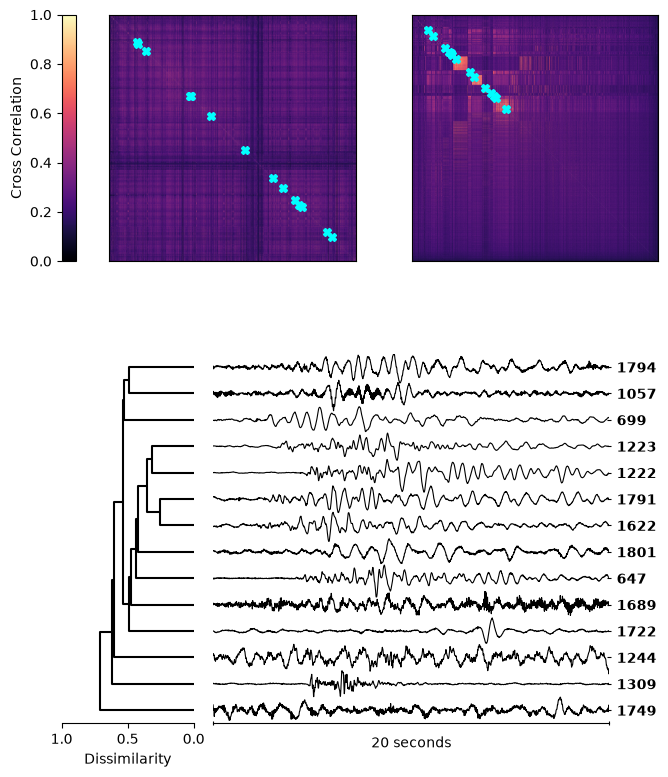

In [11]:
#now work out how to plot these nicely...

master_fig = plt.figure(figsize=(8,8))

xcorr_fig, dendro_fig = master_fig.subfigures(nrows=2,height_ratios=(2,3),hspace=0)

gs = xcorr_fig.add_gridspec(nrows=len(templates),ncols=3,width_ratios=[0.05,1,1],hspace=0,wspace=0.05)

cb_ax = xcorr_fig.add_subplot(gs[:,0])
chron_ax = xcorr_fig.add_subplot(gs[:,1])
sort_ax = xcorr_fig.add_subplot(gs[:,2])

cc_plot = chron_ax.imshow(xcorr,cmap='magma',vmin=0,vmax=1)
chron_ax.set_xticks([])
chron_ax.set_yticks([])

cc_plot = sort_ax.imshow(cc_sort,cmap='magma',vmin=0,vmax=1)
sort_ax.set_xticks([])
sort_ax.set_yticks([])

plt.colorbar(cc_plot,cax=cb_ax,label='Cross Correlation')
cb_ax.yaxis.set_ticks_position('left')
cb_ax.yaxis.set_label_position('left')
cb_ax.set_ylim(0,1)

i = 0
for clust_id, loc in template_loc.items():
    chron_ax.plot(loc,loc,marker='X',color='cyan')
    if i % 2 == 0:
        va = 'top'
    else:
        va = 'bottom'
    i += 1

for event_id, loc in event_pos.items():
    sort_ax.plot(loc,loc,marker='X',color='cyan')


dendro_gs = dendro_fig.add_gridspec(ncols=3,width_ratios = [1,3,0.4],wspace=0.1)
dend_ax = dendro_fig.add_subplot(dendro_gs[0])
waveform_ax = dendro_fig.add_subplot(dendro_gs[1])

labels = ['A','B','C','D','E','F','G','H','I','J','K','L','M','N','O','P','Q','R','S','T','U','V','W','X','Y','Z']
temp_labels = {num:labels[i] for i,num in enumerate(sort_temps.keys())}
cluster_nums = [key for key in templates.keys()]


dend_ax.spines['top'].set_visible(False)
dend_ax.spines['left'].set_visible(False)
dend_ax.spines['right'].set_visible(False)



waveform_ax.spines['top'].set_visible(False)
waveform_ax.spines['left'].set_visible(False)
waveform_ax.spines['right'].set_visible(False)

hierarchy.set_link_color_palette(['darkgreen','darkred','slategrey','peru','deeppink','olive'])

dendrogram = hierarchy.dendrogram(linkage_temp,color_threshold=0,orientation='left',ax=dend_ax,labels=cluster_nums,no_labels=True,above_threshold_color='black')

dend_ax.set_xlim(1,0)
dend_ax.set_xlabel('Dissimilarity')

old_index = None
station_names = []
for i, cluster_num in enumerate(dendrogram['ivl']):
    template_id = templates[cluster_num]
    offset = 5 + i * 10

    temp_event = full_cat.select_event(template_id)
    temp_event.attach_waveforms(inv.select(station='TI3A',channel='CHZ'),w_path,buffer=5,length=15,extra=10)
    temp_event.decimate(5)
    temp_event.filter('bandpass',freqmin=1,freqmax=30)  

    stream = temp_event.get_data_window()
    tr = stream.select(station='TI3A',channel='CHZ')[0]

    waveform_ax.plot(tr.times(),tr.data/tr.data.max()*5 + offset,lw=0.8,color='black')
    waveform_ax.set_xlim(0,20)

#sorted_y_labels = [temp_labels[key] for key in dendrogram['ivl']]
sorted_y_labels = [key for key in dendrogram['ivl']]

waveform_ax.set_ylim((0,clusters_temp.size*10))
waveform_ax.set_yticks(np.arange(0,clusters_temp.size*10,10)+5)
waveform_ax.set_yticklabels(sorted_y_labels,weight='bold')
waveform_ax.yaxis.set_ticks_position('right')

waveform_ax.set_xticks([0,20])
waveform_ax.set_xticklabels(['',''])
waveform_ax.tick_params(direction='inout')
waveform_ax.set_xlabel('20 seconds')

In [12]:
dendrogram['ivl']

['1749',
 '1309',
 '1244',
 '1722',
 '1689',
 '647',
 '1801',
 '1622',
 '1791',
 '1222',
 '1223',
 '699',
 '1057',
 '1794']

In [13]:
templates

{'647': '20190124T173258Z',
 '699': '20190115T204534Z',
 '1057': '20190123T095417Z',
 '1222': '20181227T021501Z',
 '1223': '20190118T235529Z',
 '1244': '20190118T093559Z',
 '1309': '20190108T021226Z',
 '1622': '20190119T083323Z',
 '1689': '20190103T155156Z',
 '1722': '20190101T103038Z',
 '1749': '20190117T011913Z',
 '1791': '20190101T094242Z',
 '1794': '20181226T221912Z',
 '1801': '20181227T220523Z'}

In [14]:
#tidal cycle for network catalogue.
tides = np.load('totten_tides.npz')
dt = tides['dt']
tide = tides['tide']

tide = tide[dt <= (t2 - t1)]
dt = dt[dt <= (t2 - t1)]

#analytic_signal = hilbert(tide)
#amplitude_envelope = np.abs(analytic_signal)
#instantaneous_phase = np.unwrap(np.angle(analytic_signal))
#tidal_phase = (instantaneous_phase % (2*np.pi) - np.pi) * 180/np.pi

#tidal_phase += 180
#tidal_phase[tidal_phase > 180] -= 360

KeyError: '20190103T155156Z'

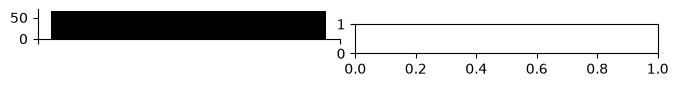

In [15]:
storm_start = UTCDateTime(2019,1,8).matplotlib_date
storm_end = UTCDateTime(2019,1,15).matplotlib_date

t1 = sh.UTCDateTime(2018,12,24)
t2 = sh.UTCDateTime(2019,1,30)

temp_cat = do.EventCatalogue(t1,t2,c_path,templates=True)

for event_id, row in temp_cat.attributes.iterrows():
    time = UTCDateTime(temp_cat.events.at[event_id,'ref_time'])
    temp_cat.attributes.at[event_id,'time'] = time.matplotlib_date

groups = temp_cat.group_split()


N_clust = len(groups)
labels = ['A','B','C','D','E','F','G','H','I','J','K','L','M','N','O']
temp_labels = {num:labels[i] for i,num in enumerate(templates.keys())}


fig = plt.figure(figsize=(8,8))
gs = fig.add_gridspec(nrows=3*(N_clust+3),ncols=2,wspace=0.05,hspace=0.0)

all_hist = []
all_tr = []

i = 0
for clust_num in groups.keys():

    hist_ax = fig.add_subplot(gs[3*i:3*i+2,0])
    tr_ax = fig.add_subplot(gs[3*i+1:3*i+3,1])

    hist_ax.patch.set_alpha(0)

    all_hist.append(hist_ax)
    all_tr.append(tr_ax)

    group_cat = groups[int(clust_num)]
    for event_id, row in group_cat.attributes.iterrows():
        time = UTCDateTime(group_cat.events.at[event_id,'ref_time'])
        group_cat.attributes.at[event_id,'time'] = time.matplotlib_date
        group_cat.attributes.at[event_id,'diurnal'] = UTCDateTime(2018,1,1,time.hour,time.minute,time.second).matplotlib_date
        delta_t = time - t1
        #group_cat.attributes.at[event_id,'phase'] = np.interp(delta_t,dt,tidal_phase)
        #group_cat.attributes.at[event_id,'height'] = np.interp(delta_t,dt,tide)

    fine_bins = np.array([time.matplotlib_date for time in np.mgrid[chunk.starttime:chunk.endtime+1:24*60*60]])
    stalta_hist, _ = np.histogram(group_cat.attributes['time'],bins=fine_bins)

    hist_ax.bar(fine_bins[:-1],stalta_hist,width=np.diff(fine_bins),color='black')
    hist_ax.spines['top'].set_visible(False)
    hist_ax.spines['right'].set_visible(False)

    myFmt = DateFormatter("%d %b")
    hist_ax.xaxis.set_major_formatter(myFmt)
    hist_ax.xaxis.set_major_locator(DayLocator(interval=7))

    plt.setp(hist_ax.get_xticklabels(), visible=False)

    if i == 4:
        hist_ax.set_ylabel('Daily Event Count')

   
    #stream = stacked_streams[int(clust_num)]

    template_id = templates[str(clust_num)]

    temp_event = network_cat.select_event(template_id)
    temp_event.attach_waveforms(inv.select(station='TI3A',channel='CHZ'),w_path,buffer=5,length=15)
    temp_event.decimate(5)
    temp_event.filter('bandpass',freqmin=1,freqmax=30)  

    t = temp_event.get_data_window().select(station='TI3A',component='Z')[0].times()

    tr_ax.plot(t,temp_event.get_data_window()[0].data,lw=1,color='black')

    try:
        stream = read(os.path.join(stack_path,'stacked_waveforms_cluster_' + str(clust_num) + '.mseed'))
        tr_ax.plot(t,stream.select(station='TI3A',component='Z')[0].data,lw=0.7,c='red')    
    except:
        print('No stacked trace yet...')
    tr_ax.set_xlim(0,20)
    

    if i != N_clust-1:
        tr_ax.set_axis_off()



    else:
        tr_ax.spines['top'].set_visible(False)
        tr_ax.spines['left'].set_visible(False)
        tr_ax.spines['right'].set_visible(False)

        tr_ax.set_xticks([0,20])
        tr_ax.set_yticks([])
        tr_ax.set_xticklabels(['',''])
        tr_ax.tick_params(direction='inout')
        tr_ax.set_xlabel('30 seconds')

    N_group = groups[int(clust_num)].N

    tr_ax.annotate('N = ' + str(N_group),(1,1.25),xycoords='axes fraction',ha='right',va='top')
    hist_ax.annotate(temp_labels[str(clust_num)],(0.01,1),xycoords='axes fraction',ha='left',va='top',weight='bold')

    #storm_box = Rectangle((storm_start,0),storm_end-storm_start,50,fc='lavender',zorder=-1)
    #hist_ax.add_patch(storm_box)

    i += 1

max_lim_hist = np.max(np.array([all_hist[i].get_ylim()[1] for i in range(N_clust)]))
max_lim_tr = np.max(np.array([np.max(np.abs(all_tr[i].get_ylim())) for i in range(N_clust)]))

for i in range(N_clust):
    all_hist[i].set_ylim(0,max_lim_hist)
    all_hist[i].set_yticks([100])

    max_y = np.max(np.abs(all_tr[i].get_ylim()))
    #all_tr[i].set_ylim(-max_lim_tr,max_lim_tr)
    all_tr[i].set_ylim(-max_y,max_y)

total_ax = fig.add_subplot(gs[3*(N_clust):3*(N_clust+1),0])
total_ax.patch.set_alpha(0)

stalta_hist, _ = np.histogram(temp_cat.attributes['time'],bins=fine_bins)

total_ax.bar(fine_bins[:-1],stalta_hist,width=np.diff(fine_bins),color='black')
total_ax.spines['top'].set_visible(False)
total_ax.spines['right'].set_visible(False)

#storm_box = Rectangle((storm_start,0),storm_end-storm_start,100,fc='lavender',zorder=-1)
#total_ax.add_patch(storm_box)

myFmt = DateFormatter("%d %b")
total_ax.xaxis.set_major_formatter(myFmt)
total_ax.xaxis.set_major_locator(DayLocator(interval=7))

plt.setp(total_ax.get_xticklabels(), visible=False)

total_ax.set_yticks([100,200])
total_ax.annotate('All',(0.01,1),xycoords='axes fraction',ha='left',va='top',weight='bold')



tide_ax = fig.add_subplot(gs[3*(N_clust+1)+1:,0],sharex=hist_ax)
tide_ax.patch.set_alpha(0)
tide_times = np.full(dt.size,fill_value=t1) + dt
tide_times_mt = np.array([time.matplotlib_date for time in tide_times])
tide_ax.plot(tide_times_mt,tide,lw=0.75,color='k')
tide_ax.set_ylim(-1.3,1.3)
tide_ax.set_ylabel('Tide Height (m)')
tide_ax.set_yticks([-1,0,1])
tide_ax.spines['top'].set_visible(False)
#tide_ax.spines['bottom'].set_visible(False)
tide_ax.spines['right'].set_visible(False)
#storm_box2 = Rectangle((storm_start,-1.3),storm_end-storm_start,17,fc='lavender',zorder=-10, clip_on=False)
#tide_ax.add_patch(storm_box2)

myFmt = DateFormatter("%d %b")
#tide_ax.xaxis.set_major_formatter(myFmt)
#tide_ax.xaxis.set_major_locator(DayLocator(interval=7))

left_fig_coords = fig.transFigure.inverted().transform(
    tide_ax.transData.transform((storm_start, -1.3))
)

right_fig_coords = fig.transFigure.inverted().transform(
    tide_ax.transData.transform((storm_end, -1.3))
)

rect = Rectangle(left_fig_coords, right_fig_coords[0]-left_fig_coords[0], 0.79, 
                         transform=fig.transFigure, 
                         color='lavender', 
                         zorder=-1)

fig.patches.append(rect)

fig.text((left_fig_coords[0]+right_fig_coords[0])/2,0.895,'STORM',ha='center',va='top',weight='bold')#,style='italic')

In [ ]:
from scipy.stats import trim_mean

In [139]:
def build_group_matrices(daychunk, c_path, buffer, window_length):
    all_traces = []
    catalogue = do.EventCatalogue(daychunk.starttime,daychunk.endtime,c_path,templates=True)
    groups = catalogue.group_split()

    X_groups = {}

    for cluster_num, group_cat in groups.items():
        for event in group_cat:
            event_stream = daychunk.stream.slice(event.starttime-buffer,event.starttime+window_length) #add buffer to help with start/end times
            all_traces.append(np.stack([tr.data for tr in event_stream],axis=0)) #stacked array of [stations,time] for each event

        X = np.stack(all_traces,axis=1) #stacked array of [stations,events,time]
        X = X - X.mean(axis=2, keepdims=True)
        #X /= np.linalg.norm(X, axis=2, keepdims=True)

        if isinstance(X, np.ma.MaskedArray):
            X = X.filled(np.nan)  # Fill masked values with np.nan

        X = np.nansum(X,axis=1)
        X_groups[cluster_num] = X

    return X_groups

In [164]:
np.stack([tr.id for tr in daychunk.stream],axis=0)

array(['1J.TI4A..CHZ', '1J.TI3A..CHZ', '1J.TI8A..CHZ', '1J.TI6A..CHZ',
       '1J.TI1A..CHZ', '1J.TI7A..CHZ'], dtype='<U12')

In [203]:

t1 = sh.UTCDateTime(2019,1,5)
t2 = sh.UTCDateTime(2019,1,10)

chunk = do.SeismicChunk(t1,t2)
all_days = []
for daychunk in chunk:
    print('Slicing data for ' + str(daychunk.starttime.date))
    daychunk.attach_waveforms(inv.select(station='TI?A',channel='CHZ'),w_path,buffer=60*60)
    daychunk.decimate(5)
    daychunk.filter('bandpass',freqmin=1,freqmax=30) #relatively low high corner to help with correlation
    X_groups = build_group_matrices(daychunk,c_path,10,20)
    all_days.append(X_groups)

Slicing data for 2019-01-05
Slicing data for 2019-01-06
Slicing data for 2019-01-07
Slicing data for 2019-01-08
Slicing data for 2019-01-09


In [204]:
temp_cat = do.EventCatalogue(t1,t2,c_path,templates=True)
group_cats = temp_cat.group_split()

stacked = {}

for clust_num in group_cats.keys():
    all_data = []
    for day in all_days:
        if clust_num in day:
            all_data.append(day[clust_num])
    all_data = np.stack(all_data,axis=1)
    #all_data = np.concat([day[clust_num] for day in all_days],axis=1)
    stacked[clust_num] = np.nansum(all_data,axis=1)

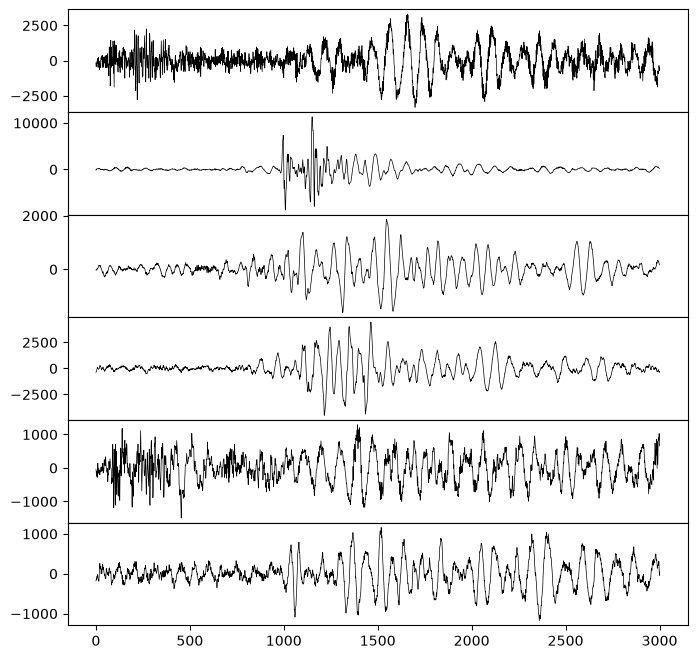

In [205]:
fig, ax = plt.subplots(figsize=(8,8),nrows=6,sharex=True,gridspec_kw={'hspace':0})

for i in range(6):
    ax[i].plot(stacked[1309][i,:],lw=0.5,c='k')

In [52]:
from scipy.stats import trim_mean
stacked = trim_mean(X_groups[1801],0.1,axis=1,nan_policy='omit')

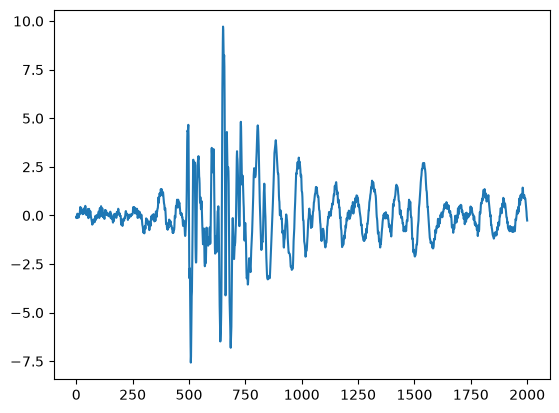

In [54]:
fig = plt.figure()
ax = fig.add_subplot(111)

ax.plot(stacked[1,:])

In [50]:

t1 = sh.UTCDateTime(2019,1,5)
t2 = sh.UTCDateTime(2019,1,6)

chunk = do.SeismicChunk(t1,t2)

channels = inv.get_contents()['channels']


window_length = 15
buffer = 5

stacked_streams = {}

temp_cat = do.EventCatalogue(t1,t2,c_path,templates=True)
groups = temp_cat.group_split()

for cluster_num, group_cat in groups.items():

    streams = []

    for daychunk in chunk:

        daychunk.attach_waveforms(inv.select(station='TI?A',channel='CHZ'),w_path,buffer=60*60)
        daychunk.decimate(5)
        daychunk.filter('bandpass',freqmin=1,freqmax=30) #relatively low high corner to help with correlation

        day_cat = do.EventCatalogue(t1,t2,c_path,templates=True)

        day_groups = day_cat.group_split()

        group_cat = day_groups[cluster_num]


        for event in tqdm(group_cat,total=group_cat.N):
            event_stream = daychunk.stream.slice(event.starttime-buffer,event.starttime+window_length) #add buffer to help with start/end times
            event_traces = np.stack([trace.data for trace in event_stream],axis=1)

            if all([len(trace) == int(100*(buffer+window_length)+1) for trace in event_stream]):
                streams.append(event_traces)


    # stacked_stream = Stream()
    # for code in channels:
    #     net,sta,loc,cha = code.split('.')
        
    #     stacked = np.stack([stream.select(network=net,station=sta,channel=cha)[0].data for stream in streams],axis=1)
    #     data = np.nanmean(stacked,axis=1)
    #     tr = Trace(data=data,header={'sampling_rate':100,'network':net,'station':sta,'location':loc,'channel':cha})
    #     stacked_stream += tr

    # stacked_stream.split()
    # stacked_streams[cluster_num] = stacked_stream

100%|██████████| 98/98 [00:00<00:00, 1061.04it/s]


: 

In [39]:
stream.select(network=net,station=sta,channel=cha)

0 Trace(s) in Stream:


In [49]:
np.array([len(stream) for stream in streams])

array([6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6])

In [40]:
stream

1 Trace(s) in Stream:
1J.TI3A..CHZ | 2018-12-26T22:19:07.120000Z - 2018-12-26T22:19:27.120000Z | 100.0 Hz, 2001 samples

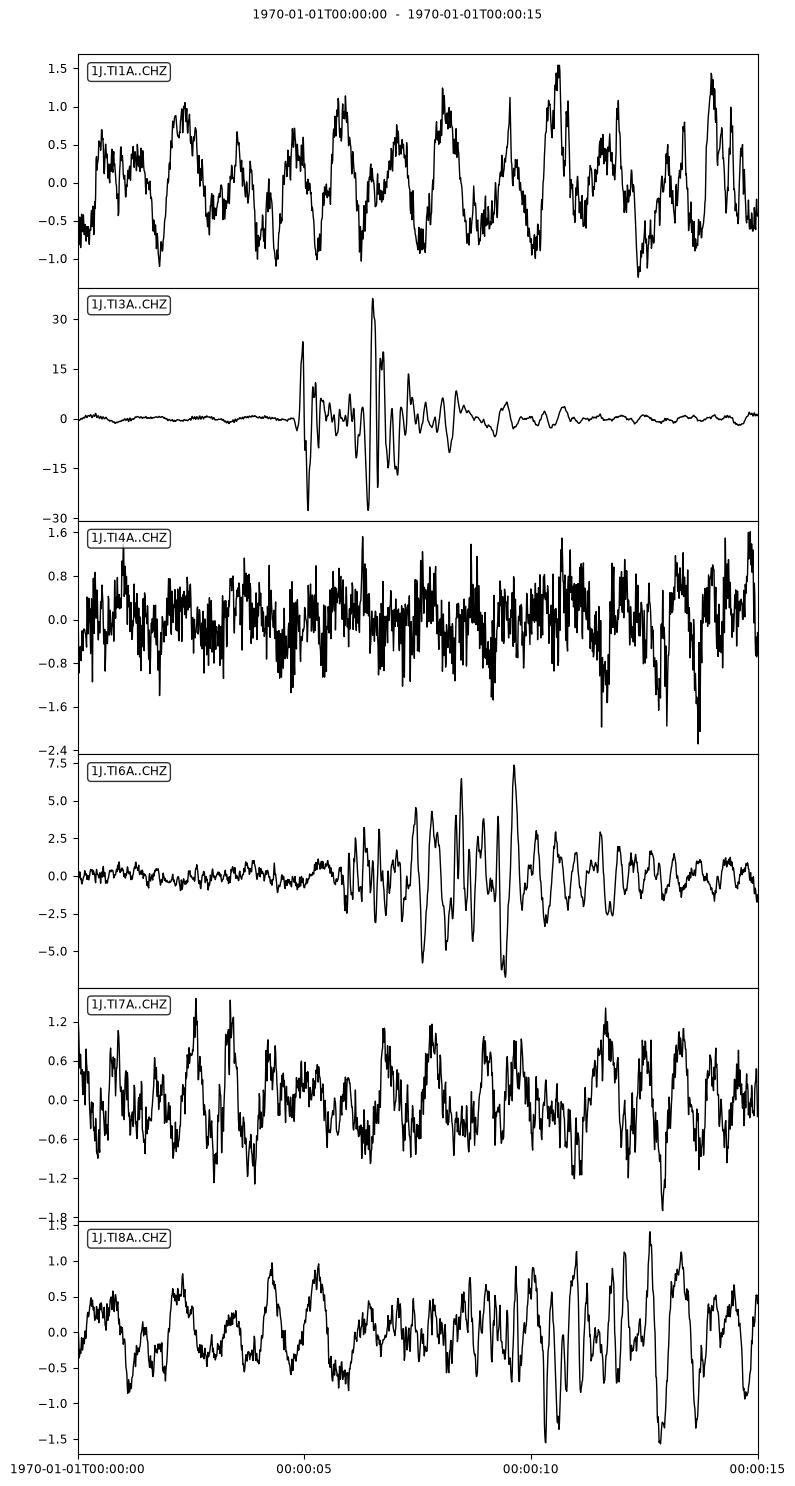

In [21]:
stacked_stream.select(component='Z').plot(equal_scale=False);

In [86]:
stream = read(os.path.join(stack_path,'stacked_waveforms_cluster_' + str(1309) + '.mseed'))

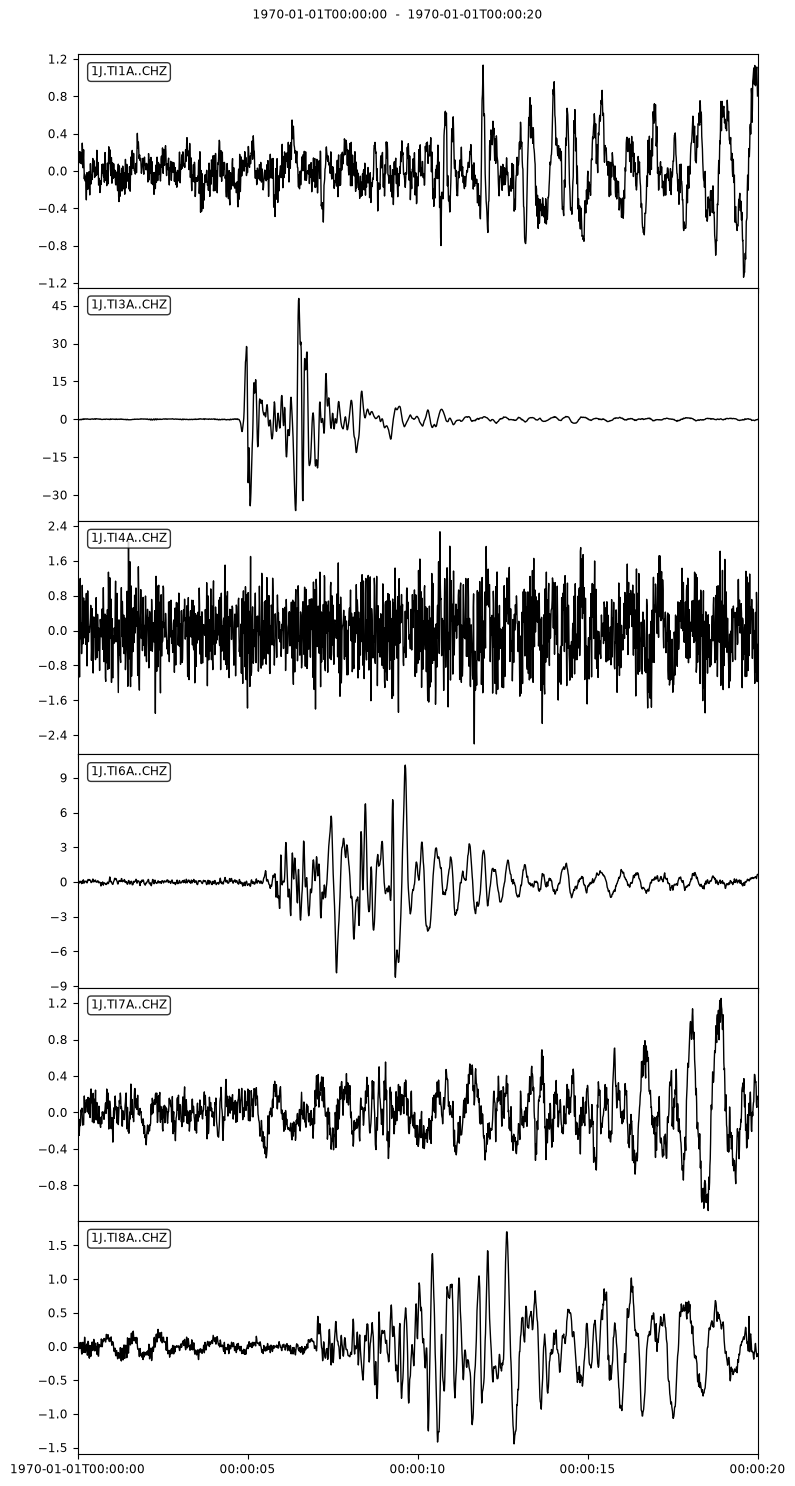

In [88]:
stream.select(component='Z').plot(equal_scale=False);

In [168]:
cluster_num = 1309

df = 100
pol_win = 0.2 #s
freq_smooth = 20
g = 4
overlap = 0.95

station='TI8A'

stream = read(os.path.join(stack_path,'stacked_waveforms_cluster_' + str(cluster_num) + '.mseed'))
stream = stream.select(station='TI?A')
#stream = stream.filter("bandpass",freqmin=1,freqmax=10)
for tr in stream:
    tr.stats.starttime = UTCDateTime(2019,1,10)
    tr.remove_response(inv,output='VEL')

substream = stream.select(station=station)

Z = substream.select(component='Z')[0]
N = substream.select(component='1')[0]
E = substream.select(component='2')[0]

#Zm, Nm, Em = sa.RollingStreamModulation(Z.data,N.data,E.data,int(pol_win*df),g=g,smooth=freq_smooth,overlap=overlap)

#Z.data = Zm
#N.data = Nm
#E.data = Em

In [169]:
fig = FigureWidgetResampler(go.Figure())
fig.add_trace(go.Scattergl(name='Modulated Waveform', showlegend=False),hf_x=Z.times(),hf_y=Z)
fig

FigureWidgetResampler({
    'data': [{'name': ('<b style="color:sandybrown">[R' ... 'tyle="color:#fc9944">~0.02</i>'),
              'showlegend': False,
              'type': 'scattergl',
              'uid': '9865f0e2-d845-45a5-ad0b-dc884f8140d9',
              'x': {'bdata': ('AAAAAAAAAAB7FK5H4XqUP3sUrkfheq' ... 'yPwvUzQHsUrkfh+jNAAAAAAAAANEA='),
                    'dtype': 'f8'},
              'y': {'bdata': ('ki82573dUL1C53KdUOC3vWNc3u8nCb' ... 'J3CyLAvc7DwGHzs7+9zeBt0DeEXz0='),
                    'dtype': 'f8'}}],
    'layout': {'template': '...'}
})

In [170]:

directory = '/Users/jaredmagyar/Documents/MappingProducts/' #! replace with path to bed topography netcdf file.
bedmap3_file = directory + 'bedmap3.nc' #! replace with name of bed topography file
bedmap3 = xr.open_dataset(bedmap3_file, engine="netcdf4")

hydrology_file = directory + '/hydrology_outputs_ll.nc'
hydrology_data = xr.open_dataset(hydrology_file, engine="netcdf4")


xmin = 2.2615e6
xmax = 2.2735e6
ymin = -1.0060e6
ymax = -0.9940e6

resolution = 25 #m

xlin = np.mgrid[xmin:xmax:resolution]
ylin = np.mgrid[ymin:ymax:resolution]

V = 3870 #m/s est
dV = 100 #m/s std

Delta = 10000 #m

a_path = root / "arrivals"



bed_grid = xr.Dataset(coords=dict(x=("x", xlin),y=("y", ylin)))
bedmap_interp = bedmap3.interp_like(bed_grid)
hydro_interp = hydrology_data.interp_like(bed_grid)
bed_grid = bed_grid.assign(dict(bed_topography = bedmap_interp.bed_topography,bed_uncertainty = bedmap_interp.bed_uncertainty,effective_pressure=hydro_interp.effective_pressure))

In [171]:
p_picks = pd.read_csv(os.path.join(a_path,'manual_picks_' + str(1309) + '.csv'),index_col=0)
p_picks['mu'] = p_picks['P1'] + (p_picks['P2'] - p_picks['P1'])/2
p_picks['sigma'] = (p_picks['P2'] - p_picks['P1'])/4

gamma_xr = sa.BedScan(inv,p_picks,bed_grid,V=3870,sigma_V=50,Delta=10000,bed_error=True,no_model_error=False)

#save the xarray dataset
#gamma_xr.to_netcdf(os.path.join(m_path,'misfit_surface_'+str(cluster_num)+'.nc'))

In [172]:
gamma = gamma_xr.gamma.to_numpy()
x_ind, y_ind = np.unravel_index(np.argmin(gamma),gamma.shape)
x_loc = xlin[x_ind]
y_loc = ylin[y_ind]

In [173]:
x_loc, y_loc

(np.float64(2270425.0), np.float64(-999850.0))

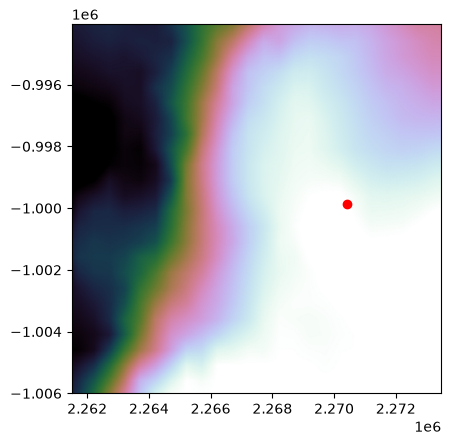

In [174]:
fig = plt.figure()
ax = fig.add_subplot(111)

ax.pcolormesh(xlin,ylin,bed_grid.effective_pressure.T,cmap='cubehelix_r',vmin=0,vmax=2e6,shading='gouraud')
ax.set_aspect('equal')
ax.scatter(x_loc,y_loc,marker='o',color='red')

In [3]:

clust_threshold = 0.15
match_threshold = 0.5
min_cluster_size = 50


t1 = sh.UTCDateTime(2018,12,24)
t2 = sh.UTCDateTime(2019,1,30)

chunk = do.SeismicChunk(t1,t2)
network_cat = do.EventCatalogue(t1,t2,c_path)

filename = c_path / 'cc_matrix_N.npz' #will need to change this to updated file path when re-processed
xcorr_file = np.load(filename, allow_pickle=True)
xcorr = xcorr_file['cc_mat']


"""
Select templates by clustering the cross-correlation matrix and selecting the most central event in each cluster.
"""

dissimilarity = 1.0-xcorr
dissimilarity = distance.squareform(dissimilarity) #flattened version - same values as dissimilary so 1 - cc_mat


linkage = fc.linkage(dissimilarity, method="single")
clusters = hierarchy.fcluster(linkage, clust_threshold, criterion="distance")

unique, counts = np.unique(clusters,return_counts=True)
clust_ind = unique[counts >= min_cluster_size]

templates = {}
template_loc = {}

for i, clust_N in enumerate(clust_ind):

    cc_ind = np.where(clusters==clust_N)[0]
    temp = xcorr[cc_ind,:]
    clust_cc = temp[:,cc_ind]

    clust_events = network_cat.events.index[cc_ind]

    central_ind = np.argmax(np.mean(clust_cc,axis=1))
    central_id = clust_events[central_ind]

    templates[str(clust_N)] = central_id
    template_loc[str(clust_N)] = network_cat.events.index.get_loc(central_id)


"""
Use the selected templates to produce a full event catalogue for the season of repeating events.
"""

#going to want to just in here and drop the templates not associated with stick-slip

templates.pop('1722')
templates.pop('1749')

full_templates = {}
full_thresholds = {}

for temp_name, temp_id in templates.items():
    template = network_cat.select_event(temp_id)
    template.attach_waveforms(inv.select(station='TI?A',channel='CHZ'),w_path,buffer=5,length=15,extra=10)
    template.decimate(5)
    template.filter('bandpass',freqmin=1,freqmax=30) 

    full_templates[temp_name] = template
    full_thresholds[temp_name] = match_threshold

In [4]:
full_templates

{'647': <cryoquake.data_objects.SeismicEvent at 0x17c40ca50>,
 '699': <cryoquake.data_objects.SeismicEvent at 0x1073bedd0>,
 '1057': <cryoquake.data_objects.SeismicEvent at 0x17d2ec190>,
 '1223': <cryoquake.data_objects.SeismicEvent at 0x17d2c8e10>,
 '1309': <cryoquake.data_objects.SeismicEvent at 0x17c2be450>,
 '1622': <cryoquake.data_objects.SeismicEvent at 0x1073cc8d0>,
 '1689': <cryoquake.data_objects.SeismicEvent at 0x17d4d3cd0>,
 '1794': <cryoquake.data_objects.SeismicEvent at 0x17c49bd50>,
 '1801': <cryoquake.data_objects.SeismicEvent at 0x17d0b2c10>}

In [5]:
full_templates['647'].stream

6 Trace(s) in Stream:
1J.TI4A..CHZ | 2019-01-24T17:32:43.100000Z - 2019-01-24T17:33:23.100000Z | 100.0 Hz, 4001 samples
1J.TI3A..CHZ | 2019-01-24T17:32:43.100000Z - 2019-01-24T17:33:23.100000Z | 100.0 Hz, 4001 samples
1J.TI8A..CHZ | 2019-01-24T17:32:43.100000Z - 2019-01-24T17:33:23.100000Z | 100.0 Hz, 4001 samples
1J.TI6A..CHZ | 2019-01-24T17:32:43.100000Z - 2019-01-24T17:33:23.100000Z | 100.0 Hz, 4001 samples
1J.TI1A..CHZ | 2019-01-24T17:32:43.100000Z - 2019-01-24T17:33:23.100000Z | 100.0 Hz, 4001 samples
1J.TI7A..CHZ | 2019-01-24T17:32:43.100000Z - 2019-01-24T17:33:23.100000Z | 100.0 Hz, 4001 samples (masked)